# Imports

In [25]:
!pip install numpy matplotlib control

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import control as ctrl
import os

# Sistema

## Definición de la planta

In [27]:
os.makedirs("figuras", exist_ok=True) # Para guardar todas las figuras en una sola carpeta

K     = 1.0   # Ganancia
J     = 1.0   # Momento de inercia
B_nom  = 0.5  # Coeficiente de fricción nominal
B_fail = -0.1 # Coeficiente de fricción con falla


def make_plant(B):
    """Función de transferencia de la planta G(s) = K/(s*(J*s+B))"""
    return ctrl.tf([K], [J, B, 0])


def make_cl(G, C=None):
    """Sistema en lazo cerrado con realimentación unitaria."""
    if C is None:
        C = ctrl.tf([1], [1])
    return ctrl.feedback(C * G, 1)

## Parte A

### Inciso a

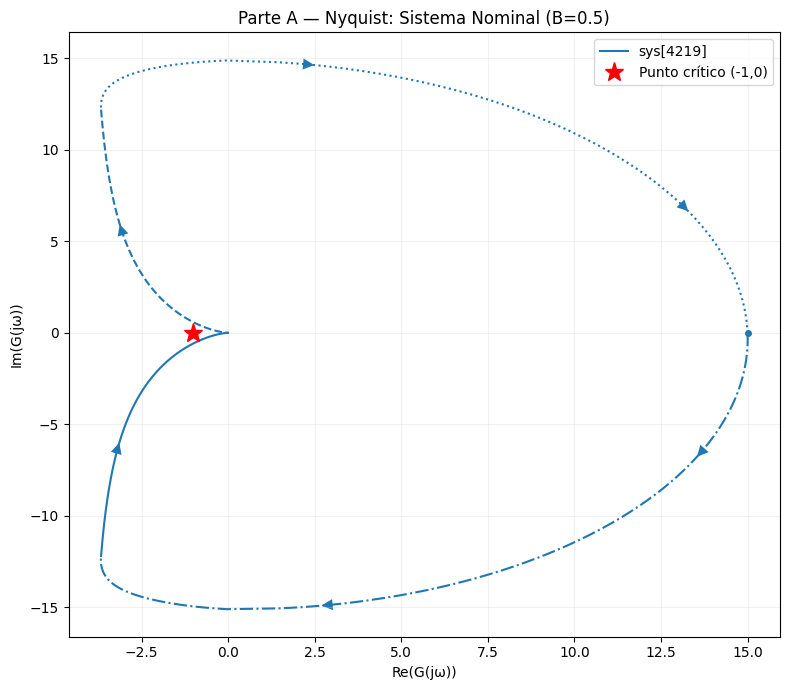

  Polos de G(s) en lazo abierto: [-0.5+0.j  0. +0.j]
  Margen de Ganancia: inf (inf dB)
  Margen de Fase: 28.02°
  → P=0 (sin polos en RHP), N=0 (sin encerramiento de -1+j0)
  → Z = N + P = 0  →  Sistema ESTABLE en lazo cerrado


In [28]:
G_nom = make_plant(B_nom)

fig, ax = plt.subplots(figsize=(8, 7))
_ = ctrl.nyquist_plot(G_nom, plot=True, ax=ax) #Grafico el Nyquist del sistema nominal
ax.plot(-1, 0, "r*", markersize=14, zorder=5, label="Punto crítico (-1,0)")
ax.set_title("Parte A — Nyquist: Sistema Nominal (B=0.5)")
ax.set_xlabel("Re(G(jω))")
ax.set_ylabel("Im(G(jω))")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figuras/A_a_nyquist_nominal.png", dpi=150)
plt.show()
plt.close()

# Análisis de estabilidad por Nyquist
poles_ol = ctrl.poles(G_nom)
gm, pm, wg, wp = ctrl.margin(G_nom)

print(f"  Polos de G(s) en lazo abierto: {poles_ol}")
print(f"  Margen de Ganancia: {gm:.3f} ({20*np.log10(gm):.2f} dB)")
print(f"  Margen de Fase: {pm:.2f}°")
print("  → P=0 (sin polos en RHP), N=0 (sin encerramiento de -1+j0)")
print("  → Z = N + P = 0  →  Sistema ESTABLE en lazo cerrado")

### Inciso b

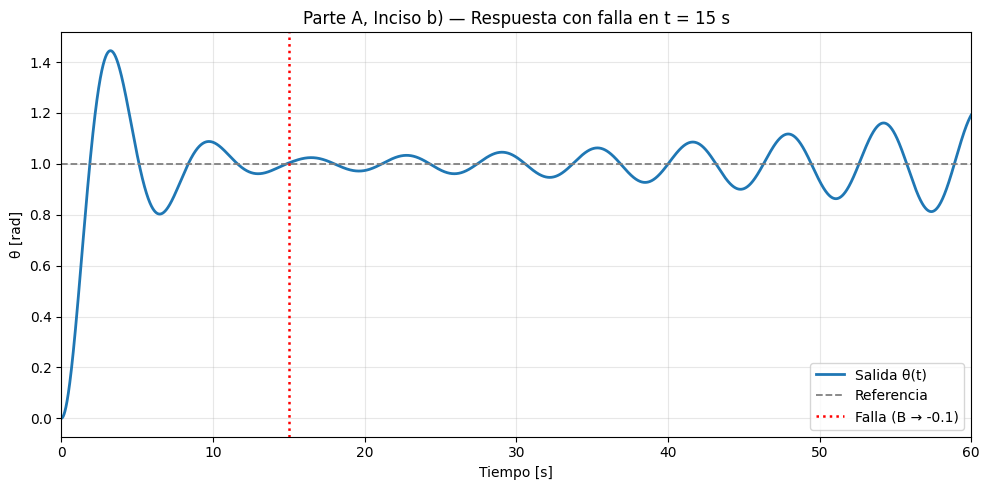

  Polos del LC con falla: [0.05+0.99874922j 0.05-0.99874922j]
  Sistema con falla: INESTABLE


In [29]:
G_fail = make_plant(B_fail)
CL_nom_ss  = ctrl.ss(make_cl(G_nom)) # Lazo cerrado nominal en espacio de estados
CL_fail_ss = ctrl.ss(make_cl(G_fail)) #Lazo cerrado con falla en espacio de estados

dt  = 0.005
t1  = np.arange(0, 15 + dt, dt)
t2r = np.arange(0, 45 + dt, dt)   # relativo desde t=15

# Tramo 1: sistema nominal (0 a 15 s)
_, y1, xout = ctrl.forced_response(
    CL_nom_ss, T=t1, U=np.ones_like(t1),
    X0=np.zeros(CL_nom_ss.nstates), return_x=True
)
x0_at_15 = xout[:, -1]  # estado inicial para la falla

# Tramo 2: sistema con falla (15 s en adelante)
_, y2 = ctrl.forced_response(
    CL_fail_ss, T=t2r, U=np.ones_like(t2r), X0=x0_at_15
)
# saco el ultimo y primer punto de los tramos para no duplicarlo.
t_full = np.concatenate([t1, t2r[1:] + 15])
y_full = np.concatenate([y1, y2[1:]])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t_full, y_full, linewidth=2, label="Salida θ(t)")
ax.axhline(1, color="gray", linestyle="--", linewidth=1.3, label="Referencia")
ax.axvline(15, color="red", linestyle=":", linewidth=1.8, label="Falla (B → -0.1)")
ax.set_title("Parte A, Inciso b) — Respuesta con falla en t = 15 s")
ax.set_xlabel("Tiempo [s]")
ax.set_ylabel("θ [rad]")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 60])
plt.tight_layout()
plt.savefig("figuras/A_b_respuesta_falla.png", dpi=150)
plt.show()
plt.close()

poles_cl_fail = ctrl.poles(make_cl(G_fail)) # Calculo los polos
print(f"  Polos del LC con falla: {poles_cl_fail}")

inestable = any(p.real > 0 for p in poles_cl_fail) # Chequeo estabilidad
print(f"  Sistema con falla: {'INESTABLE' if inestable else 'ESTABLE'}")

### Inciso c

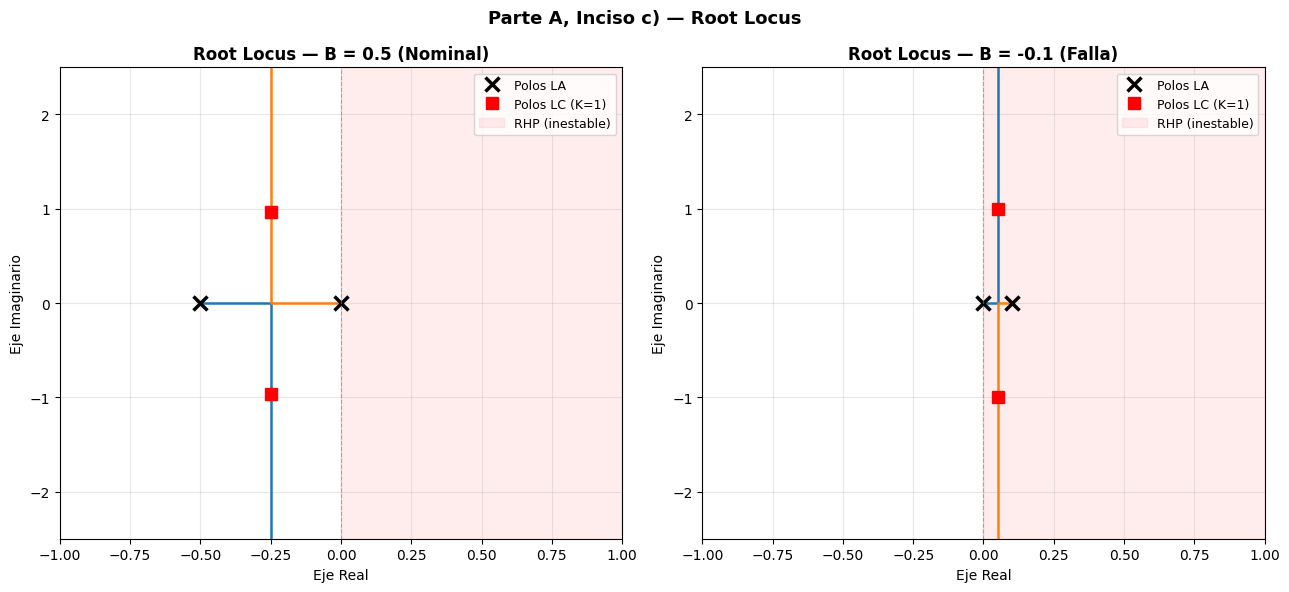

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
casos = [(G_nom, B_nom, "Nominal"), (G_fail, B_fail, "Falla")]

for ax, (G, B, lbl) in zip(axes, casos):
    rlocus_data = ctrl.root_locus_map(G) # Root locus de las dos plantas
    rlist = rlocus_data.loci

    for branch in rlist.T: # Se transpone porque cada columna es un polo segun k
        ax.plot(branch.real, branch.imag, linewidth=1.8)

    poles_ol = ctrl.poles(G) # polos a lazo abierto
    poles_cl = ctrl.poles(make_cl(G)) # polos a lazo cerrado

    ax.plot(poles_ol.real, poles_ol.imag, "kx", markersize=10, markeredgewidth=2.5,
            label="Polos LA")
    ax.plot(poles_cl.real, poles_cl.imag, "rs", markersize=8, label="Polos LC (K=1)")
    ax.axvline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.6)
    ax.fill_betweenx([-2.5, 2.5], 0, 1, alpha=0.07, color="red", label="RHP (inestable)")
    ax.set_title(f"Root Locus — B = {B} ({lbl})", fontweight="bold")
    ax.set_xlabel("Eje Real")
    ax.set_ylabel("Eje Imaginario")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([-1, 1])
    ax.set_ylim([-2.5, 2.5])

plt.suptitle("Parte A, Inciso c) — Root Locus", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figuras/A_c_root_locus.png", dpi=150)
plt.show()
plt.close()

## Parte B

### Inciso a


In [35]:
def make_lead(pc, zc=1.0):
    return ctrl.tf([pc / zc, pc], [1, pc])

def loop_tf(pc):
    """Función de lazo abierto: L(s) = C_lead(s) · G_nom(s)"""
    return make_lead(pc) * G_nom

def phase_margin_of(pc):
    """Devuelve solo el margen de fase para un pc dado (descarta gm, wpc, wgc de ctrl.margin). Solo para que yo pueda seguir mejor el codigo y debuggear"""
    _, pm_val, _, _ = ctrl.margin(loop_tf(pc))
    return pm_val

def get_wgc(L, omega=np.logspace(-2, 3, 5000)):
    """
    Calcula la frecuencia de cruce de ganancia (|L(jω)| = 1) por interpolación lineal.
    Se usa interpolación en lugar de un solver para evitar depender de la densidad
    de la grilla de frecuencias. Retorna np.nan si no existe cruce.
    """
    resp = ctrl.frequency_response(L, omega)
    mag  = np.abs(resp.fresp.squeeze())
    idx  = np.where(np.diff(np.sign(mag - 1.0)))[0] # Detecta índices donde la magnitud cruza 1.0 (cambio de signo de mag-1)
    if len(idx) == 0:
        return np.nan
    # Interpolación lineal entre los dos puntos que flanquean el cruce
    w0, w1 = omega[idx[0]], omega[idx[0]+1]
    m0, m1 = mag[idx[0]], mag[idx[0]+1]
    return w0 + (1.0 - m0) * (w1 - w0) / (m1 - m0) # Regla de tres sobre la magnitud

# ─── Barrido ─────────────────────────────────────────────────────────────────
pc_sweep = np.linspace(1.01, 10, 1000)
pm_sweep = np.array([phase_margin_of(pc) for pc in pc_sweep])

targets = [35.0, 50.0, 65.0]
results = {}

for tgt in targets:
    idx    = np.nanargmin(np.abs(pm_sweep - tgt)) # Se elige el pc cuyo MF real es más cercano al objetivo
    pc_opt = pc_sweep[idx]
    pm_got = pm_sweep[idx]
    L      = loop_tf(pc_opt)
    wgc    = get_wgc(L)
    dc_gain = float(np.real(ctrl.dcgain(make_lead(pc_opt)))) # Evito ComplexWarning
    results[tgt] = {"pc": pc_opt, "pm": pm_got, "wgc": wgc, "dc": dc_gain}
    print(f"  MF = {tgt}°  →  pc = {pc_opt:.4f},  MF real = {pm_got:.2f}°,"
          f"  ωgc = {wgc:.4f} rad/s,  DC gain = {dc_gain:.4f}")

  MF = 35.0°  →  pc = 1.3610,  MF real = 35.01°,  ωgc = 1.0117 rad/s,  DC gain = 1.0000
  MF = 50.0°  →  pc = 2.7468,  MF real = 50.00°,  ωgc = 1.1295 rad/s,  DC gain = 1.0000
  MF = 65.0°  →  pc = 8.7491,  MF real = 65.00°,  ωgc = 1.1925 rad/s,  DC gain = 1.0000


### Inciso b


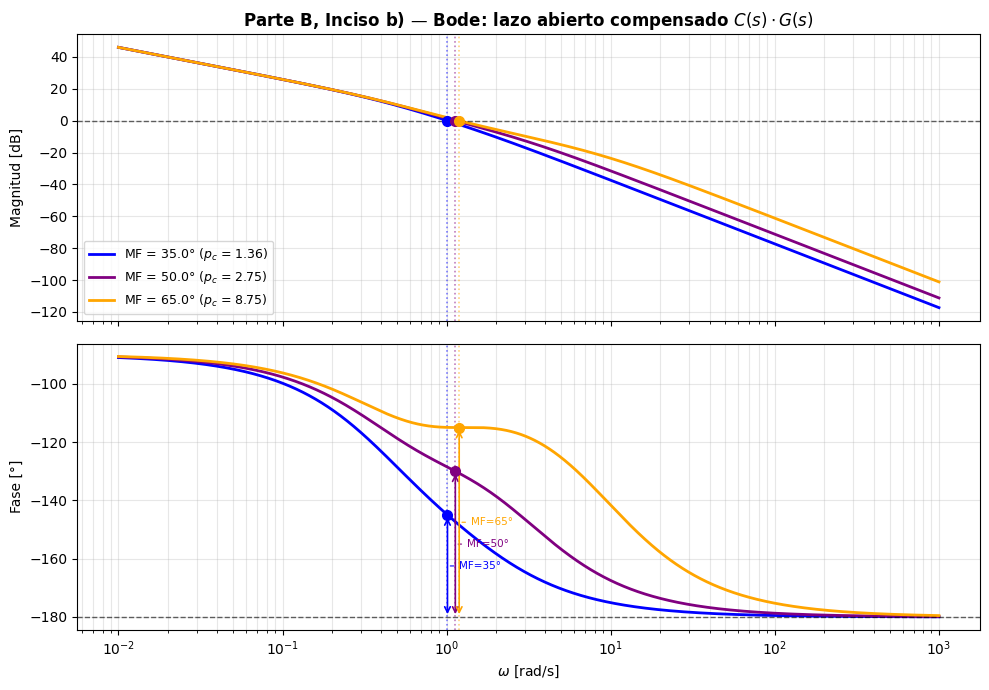

In [32]:
omega_b = np.logspace(-2, 3, 3000)
colors = ['blue', 'purple','orange']
fig, (ax_mag, ax_ph) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# Curvas de Bode para cada compensador diseñado
for tgt, col in zip(targets, colors):
    pc  = results[tgt]["pc"]
    wgc = results[tgt]["wgc"]
    L   = loop_tf(pc)

    mag, phase, omega_out = ctrl.bode(L, omega=omega_b, plot=False) # no grafico con ctrl
    mag_db  = 20 * np.log10(mag)
    phase_d = np.degrees(phase)

    # Fase interpolada en ωgc
    phase_at_wgc = np.interp(wgc, omega_out, phase_d)
    pm_val = 180 + phase_at_wgc   # margen de fase = 180 + fase(ωgc)

    lbl = f"MF = {tgt}° ($p_c$ = {pc:.2f})"
    ax_mag.semilogx(omega_out, mag_db,  color=col, linewidth=2, label=lbl)
    ax_ph.semilogx( omega_out, phase_d, color=col, linewidth=2)

    ax_mag.axvline(wgc, color=col, linestyle=":", linewidth=1.2, alpha=0.5)
    ax_ph.axvline( wgc, color=col, linestyle=":", linewidth=1.2, alpha=0.5)

    ax_mag.plot(wgc, 0, marker="o", color=col, markersize=7, zorder=5)

    ax_ph.plot(wgc, phase_at_wgc, marker="o", color=col, markersize=7, zorder=5)

    # Segmento vertical que muestra visualmente el margen de fase
    ax_ph.annotate("", xy=(wgc, -180), xytext=(wgc, phase_at_wgc),
                   arrowprops=dict(arrowstyle="<->", color=col, lw=1.2))
    ax_ph.annotate(f"MF={pm_val:.0f}°",
                   xy=(wgc, (phase_at_wgc - 180) / 2),
                   xytext=(wgc * 1.18, (phase_at_wgc - 180) / 2),
                   color=col, fontsize=7.5, va="center",
                   arrowprops=dict(arrowstyle="-", color=col, lw=0.8))

ax_mag.axhline(0,   color="k", linestyle="--", linewidth=1, alpha=0.6)
ax_ph.axhline(-180, color="k", linestyle="--", linewidth=1, alpha=0.6)

ax_mag.set_ylabel("Magnitud [dB]")
ax_mag.set_title("Parte B, Inciso b) — Bode: lazo abierto compensado $C(s)\\cdot G(s)$",
                 fontweight="bold")
ax_mag.legend(fontsize=9, loc="lower left")
ax_mag.grid(True, alpha=0.3, which="both")

ax_ph.set_ylabel("Fase [°]")
ax_ph.set_xlabel("$\\omega$ [rad/s]")
ax_ph.grid(True, alpha=0.3, which="both")

plt.tight_layout()
plt.savefig("figuras/B_b_bode_compensados.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

### Inciso c

  MF = 35.0°  →  ts (2%) = 10.06 s
  MF = 50.0°  →  ts (2%) = 5.95 s
  MF = 65.0°  →  ts (2%) = 4.88 s


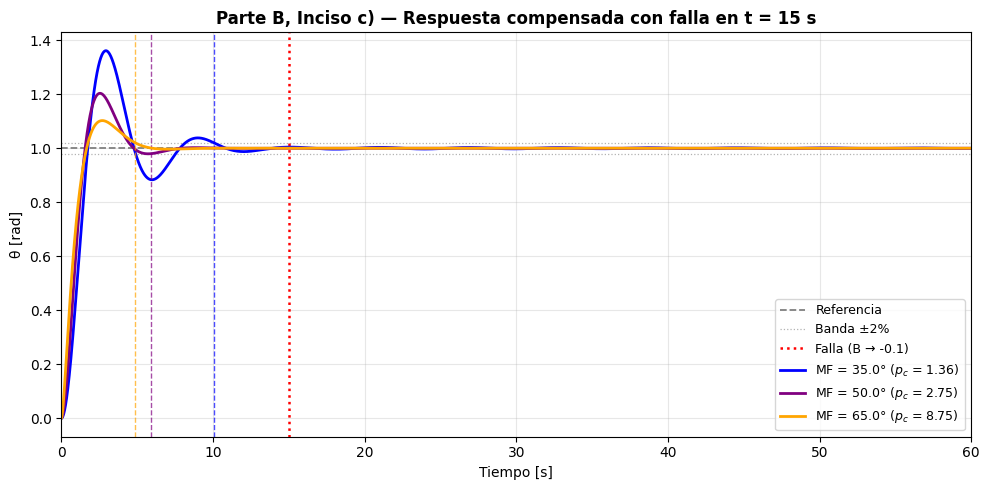

In [33]:
dt  = 0.005
t1  = np.arange(0, 15 + dt, dt)
t2r = np.arange(0, 45 + dt, dt)   # relativo desde t=15


fig, ax = plt.subplots(figsize=(10, 5))
ax.axhline(1,    color="gray", linestyle="--", linewidth=1.3, label="Referencia")
ax.axhline(1.02, color="gray", linestyle=":",  linewidth=0.9, alpha=0.6)
ax.axhline(0.98, color="gray", linestyle=":",  linewidth=0.9, alpha=0.6, label="Banda ±2%")
ax.axvline(15,   color="red",  linestyle=":",  linewidth=1.8, label="Falla (B → -0.1)")


for tgt, col in zip(targets, colors):
    pc = results[tgt]["pc"]
    C  = make_lead(pc)

    CL_nom_c  = ctrl.ss(make_cl(G_nom,  C))
    CL_fail_c = ctrl.ss(make_cl(G_fail, C))

    # Tramo 1: nominal (0 → 15 s)
    _, y1, xout = ctrl.forced_response(
        CL_nom_c, T=t1, U=np.ones_like(t1),
        X0=np.zeros(CL_nom_c.nstates), return_x=True
    )
    x0_15 = xout[:, -1]

    # Tramo 2: con falla (desde t=15 s)
    _, y2 = ctrl.forced_response(
        CL_fail_c, T=t2r, U=np.ones_like(t2r), X0=x0_15
    )

    t_f = np.concatenate([t1, t2r[1:] + 15])
    y_f = np.concatenate([y1, y2[1:]])

    ax.plot(t_f, y_f, color=col, linewidth=2,
            label=f"MF = {tgt}° ($p_c$ = {pc:.2f})")

    # Tiempo de establecimiento (criterio 2%)
    banda = 0.02
    fuera = np.where(np.abs(y_f - 1.0) > banda)[0]

    if len(fuera) == 0:
        ts = t_f[0]   # nunca salió de la banda (raro)
    else:
        ts = t_f[fuera[-1]]   # último instante fuera de la banda

    # Marcar ts en el gráfico
    ax.axvline(ts, color=col, linestyle="--", linewidth=1.0, alpha=0.7)

    print(f"  MF = {tgt}°  →  ts (2%) = {ts:.2f} s")

ax.set_title("Parte B, Inciso c) — Respuesta compensada con falla en t = 15 s",
             fontweight="bold")
ax.set_xlabel("Tiempo [s]")
ax.set_ylabel("θ [rad]")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 60])
plt.tight_layout()
plt.savefig("figuras/B_c_respuesta_compensada.png", dpi=150)
plt.show()
plt.close()

### Inciso d

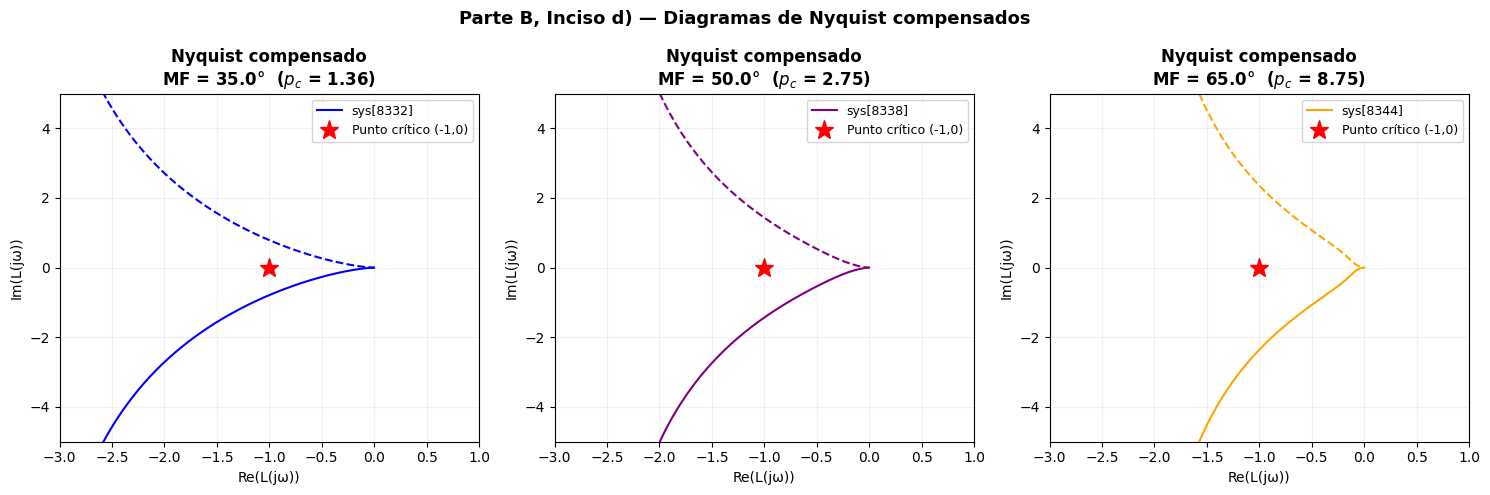

  MF = 35.0°  →  dist. mínima al punto crítico ≈ 0.5311
  MF = 50.0°  →  dist. mínima al punto crítico ≈ 0.7147
  MF = 65.0°  →  dist. mínima al punto crítico ≈ 0.8947


In [36]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, tgt, col in zip(axes, targets, colors):
    pc = results[tgt]["pc"]
    L  = loop_tf(pc)

    _ = ctrl.nyquist_plot(L, plot=True, ax=ax, color=col) # ctrl.nyquist_plot dibuja tanto la curva positiva (ω > 0) como su espejo (ω < 0)
    ax.plot(-1, 0, "r*", markersize=14, zorder=5, label="Punto crítico (-1,0)")
    ax.set_title(f"Nyquist compensado\nMF = {tgt}°  ($p_c$ = {pc:.2f})",
                 fontweight="bold")
    ax.set_xlabel("Re(L(jω))")
    ax.set_ylabel("Im(L(jω))")
    ax.set_xlim([-3, 1])
    ax.set_ylim([-5, 5])
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle("Parte B, Inciso d) — Diagramas de Nyquist compensados",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figuras/B_d_nyquist_compensados.png", dpi=150)
plt.show()
plt.close()

for tgt in targets:
    r   = results[tgt]
    pc  = r["pc"]
    L   = loop_tf(pc)
    # Distancia mínima de la curva de Nyquist al punto crítico (-1,0)
    omega_fine = np.logspace(-2, 3, 20000)
    s_fine     = 1j * omega_fine
    Ljw        = pc * (s_fine + 1) / (s_fine + pc) / (s_fine * (s_fine + B_nom))
    dist       = np.min(np.abs(Ljw + 1))
    print(f"  MF = {tgt}°  →  dist. mínima al punto crítico ≈ {dist:.4f}")
